<a href="https://colab.research.google.com/github/danamelissamendoza/Talleres-del-curso-IA-aplicada-a-la-economia/blob/main/Taller_KNN_arbol_Vasquez_Mendoza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_KNN_arbol_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/3br4TfA3Ly.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/4_Taller_KNN_y_Arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller KNN y Árboles de Decisión**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Manuela Vásquez Osorio
- Dana Melissa Mendoza Santiago.
-

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_KNN_arbol_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/3br4TfA3Ly.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

7 de mayo de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.



### **Contexto del Caso**

Un banco portugués lo ha contratado como consultor de ciencia de datos. El banco tiene un problema de eficiencia: sus campañas de telemercadeo para ofrecer depósitos a plazo tienen una tasa de éxito muy baja. Se invierte mucho tiempo y recursos (costos de call center) llamando a clientes que no están interesados.

**Su misión:** Construir y optimizar modelos de Machine Learning que predigan qué clientes tienen mayor probabilidad de decir **"sí"** a la oferta (`y = 'yes'`).

El banco no solo quiere un modelo preciso, también quiere entender **POR QUÉ** un cliente es un buen prospecto. Su segundo objetivo es identificar cuáles son las **variables más relevantes** que usan los modelos para tomar sus decisiones. Esto permitirá al banco no solo enfocar sus llamadas, sino también crear mejores guiones de marketing y entender mejor a su clientela.

**El Dataset:** `bank-additional.csv` se encuentra en el repositorio del curso. Contiene información de más de 4.000 contactos de telemercadeo, incluyendo datos demográficos del cliente e información de la campaña (último contacto, resultado anterior).

**Para mayor información y descripción de las variables:** https://archive.ics.uci.edu/dataset/222/bank+marketing

## 1. Preparación del Entorno y Datos

### 1.1. Carga de Librerías

Importe todas las librerías necesarias. Para problemas de clasificación se usa KNeighborsClassifier y DecisionTreeClassifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix


Mejorar visualización de dataframes y gráficos

In [2]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Carga y Exploración Inicial

In [20]:
# 1.2.1: Cargue el dataset
# ### TU CÓDIGO AQUÍ ###
# Usa sep=';'
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv(
    '/content/drive/MyDrive/5_Aprendizaje_supervisado/bank-additional.csv',
    sep=';'
)
df.drop(columns=['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace=True)

# 1.2.2: Muestre las primeras 5 filas
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,no


In [6]:
# 1.2.3: Use .info() para revisar los tipos de datos y los nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          4119 non-null   int64 
 1   job          4119 non-null   object
 2   marital      4119 non-null   object
 3   education    4119 non-null   object
 4   default      4119 non-null   object
 5   housing      4119 non-null   object
 6   loan         4119 non-null   object
 7   contact      4119 non-null   object
 8   month        4119 non-null   object
 9   day_of_week  4119 non-null   object
 10  campaign     4119 non-null   int64 
 11  pdays        4119 non-null   int64 
 12  previous     4119 non-null   int64 
 13  poutcome     4119 non-null   object
 14  y            4119 non-null   object
dtypes: int64(4), object(11)
memory usage: 482.8+ KB


**Escriba un análisis de lo obseervado en `info()`:**
Dado el tipo de datos de la base, qué preprocesamientos hay que realizar antes de correr los modelos?

Al analizar el resultado de info(), se observa que la base de datos tiene 4119 registros y 15 variables. Además, no hay valores nulos, por lo que no es necesario eliminar datos ni rellenar información faltante.

La base contiene variables numéricas, como age, campaign, pdays y previous, y muchas variables categóricas de texto, como job, education, contact y month. Como los modelos de machine learning no trabajan directamente con texto, es necesario transformar estas variables usando One Hot Encoding, que convierte cada categoría en variables numéricas.

Además, para el modelo KNN es importante escalar las variables numéricas con StandardScaler, ya que este algoritmo funciona con distancias y necesita que todas las variables estén en escalas similares.

Finalmente, antes de entrenar los modelos, se deben separar las variables predictoras de la variable objetivo y dividir los datos en entrenamiento y prueba para poder evaluar correctamente el desempeño del modelo.

In [7]:
# 1.2.4: Revise el balance de la variable objetivo 'y'
# Use .value_counts() con normalize=True

df['y'].value_counts(normalize=True)


,proportion
y,
no,0.89
yes,0.11


**Escriba un análisis de la variable objetivo:**
¿Es un dataset desbalanceado? ¿Esto tiene lógica? ¿Qué implicaciones tiene esto respecto a las métricas que debemos usar?

**¿Es un dataset desbalanceado?**

Al analizar la variable objetivo y, se observa que el 89% de los clientes pertenecen a la categoría "no" y solo el 11% a "yes". Esto indica que el dataset está desbalanceado, ya que hay muchos más casos de una clase que de la otra.

**¿Esto tiene lógica?**

En este contexto en partícular, este comportamiento tiene lógica ya que corresponde a campañas de marketing bancario para ofrecer depósitos a término y la mayoría de los clientes normalmente rechazan este tipo de ofertas, mientras que solo una pequeña proporción acepta el producto financiero. Por tanto, es esperable encontrar muchos más casos negativos que positivos.

**¿Qué implicaciones tiene esto respecto a las métricas que debemos usar?**

El desbalance afecta la evaluación del modelo, ya que usar solo el accuracy puede ser engañoso. Por ejemplo, un modelo que siempre prediga "no" tendría cerca de 89% de accuracy, pero no serviría para identificar a los clientes que sí comprarían.
Por eso es mejor usar métricas como Recall, Precision y F1-score, especialmente para la clase "yes". El recall es muy importante porque mide qué tan bien el modelo logra identificar a los clientes que realmente aceptarían la oferta.

## 2. Preprocesamiento (Usando Pipelines)

Vamos a definir nuestro `X` e `y`, y luego crear un `ColumnTransformer` que se encargue de aplicar `StandardScaler` a los números y `OneHotEncoder` a las categorías.

In [8]:
# 2.1: Separe X (predictoras) e y (objetivo)
X = df.drop('y', axis=1)
y = df['y']


In [9]:
# 2.2: Divida en train y test (80/20)
# ¡Use stratify=y para mantener la proporción de 'yes' y 'no' en ambos sets!
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño Train: {X_train.shape}")
print(f"Tamaño Test: {X_test.shape}")


print(f"Tamaño Train: {X_train.shape}")
print(f"Tamaño Test: {X_test.shape}")

Tamaño Train: (3295, 14)
Tamaño Test: (824, 14)
Tamaño Train: (3295, 14)
Tamaño Test: (824, 14)


In [12]:
# 2.3: Identifique automáticamente las columnas numéricas y categóricas

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

print("Columnas Numéricas:")
print(numerical_features)

print("\nColumnas Categóricas:")
print(categorical_features)


print("Columnas Numéricas:")
print(numerical_features)
print("\nColumnas Categóricas:")
print(categorical_features)

Columnas Numéricas:
Index(['age', 'campaign', 'pdays', 'previous'], dtype='object')

Columnas Categóricas:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')
Columnas Numéricas:
Index(['age', 'campaign', 'pdays', 'previous'], dtype='object')

Columnas Categóricas:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')


In [15]:
# 2.4: Cree el ColumnTransformer (preprocessor) para estandarizar las variables numéricas y
# realizar One-Hot-Encoding de las variables categóricas

# Crear los transformadores individuales
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(handle_unknown='ignore')
# handle_unknown='ignore' es clave


# Unirlos en el preprocesador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

## 3. Modelo 1: KNN

Ahora uniremos el preprocesador y el clasificador KNN en un solo `Pipeline` y usaremos `GridSearchCV` para encontrar el mejor `k`.

In [16]:
# 3.1: Cree el Pipeline completo de KNN
# (una el 'preprocessor' con el modelo 'KNeighborsClassifier')

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier())
])

# 3.2: Definir la grilla de hiperparámetros para KNN
# Queremos probar k = 3, 5, 7, 11 (valores impares para evitar empates)
# Pista: El nombre DEBE ser 'model__n_neighbors' (por el nombre en el pipeline)

param_grid_knn = {
    'model__n_neighbors': [3, 5, 7, 11]
}

# 3.3: Configurar y ejecutar GridSearchCV
# Use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.

grid_knn = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    cv=3,
    scoring='recall_macro'
)

grid_knn.fit(X_train, y_train)



# 3.4: Mostrar los mejores resultados
print(f"Mejor valor de 'k' para KNN: {grid_knn.best_params_}")
print(f"Mejor Recall-Macro: {grid_knn.best_score_:.4f}")

Mejor valor de 'k' para KNN: {'model__n_neighbors': 3}
Mejor Recall-Macro: 0.5922


## 4. Modelo 2: Árbol de Decisión

Repetiremos el proceso con un Árbol de Decisión. Esta vez, los hiperparámetros que ajustaremos serán `max_depth` (para evitar sobreajuste) y `min_samples_leaf`.

In [17]:
# 4.1: Crear el Pipeline completo para el Árbol de Decisión
# (une el 'preprocessor' con el modelo 'DecisionTreeClassifier')

tree_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

# 4.2: Definir la grilla de hiperparámetros para el Árbol
# Probaremos 'max_depth' = [3, 5, 7]
# Y 'min_samples_leaf' = [20, 50, 100] (para controlar la complejidad)

param_grid_tree = {
    'model__max_depth': [3, 5, 7],
    'model__min_samples_leaf': [20, 50, 100]
}

# 4.3: Configurar y ejecutar GridSearchCV
# Al igual que en KNN, use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.
grid_tree = GridSearchCV(
    tree_pipeline,
    param_grid_tree,
    cv=3,
    scoring='recall_macro'
)

grid_tree.fit(X_train, y_train)


# 4.4: Mostrar los mejores resultados
print(f"Mejores hiperparámetros para el Árbol: {grid_tree.best_params_}")
print(f"Mejor Recall-Macro: {grid_tree.best_score_:.4f}")

Mejores hiperparámetros para el Árbol: {'model__max_depth': 3, 'model__min_samples_leaf': 50}
Mejor Recall-Macro: 0.6013


## 5. Evaluación Final y Recomendación de Modelo

El Árbol de Decisión probablemente dio un mejor `recall-macro` (y es más rápido e interpretable). Vamos a declararlo nuestro **modelo ganador** y evaluarlo en el `test set` (nuestro examen final imparcial).

In [18]:
# 5.1: Obtener el mejor modelo de árbol (el 'best_estimator_')

best_tree_model = grid_tree.best_estimator_

# 5.2: Realizar predicciones sobre el conjunto de PRUEBA (X_test)

y_pred_tree = best_tree_model.predict(X_test)

# 5.3: Imprimir el Reporte de Clasificación
print("--- Reporte de Clasificación Final (Árbol Optimizado) ---")
print(classification_report(y_test, y_pred_tree))


--- Reporte de Clasificación Final (Árbol Optimizado) ---
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.74      0.19      0.30        90

    accuracy                           0.90       824
   macro avg       0.82      0.59      0.62       824
weighted avg       0.89      0.90      0.88       824



**Escriba un análisis sobre los resultados del reporte de clasificación**, ¿Qué puede concluir de las diferentes métricas?

* Observe el `accuracy` general (probablemente ~90%).
* Ahora mire la fila de `'yes'`: ¿Cuál es el `precision`? ¿Cuál es el `recall`?
* **Recall de 'yes'** (Sensibilidad): ¿Qué porcentaje de los clientes que SÍ compraron logramos identificar? (Usualmente lo más importante para el banco, para no perder oportunidades).
* **Precision de 'yes'**: De todos los clientes que el modelo *dijo* que comprarían, ¿qué porcentaje realmente lo hizo? (Importante para no gastar llamadas).

**Responda aquí**



El modelo obtiene un accuracy general de 90%, lo que parece un muy buen resultado. Sin embargo, como el dataset está desbalanceado y la mayoría de los clientes pertenecen a la clase "no".

El análisis para la clase "yes". El precision es 0.74, lo que indica que el 74% de los clientes que el modelo predijo como compradores realmente compraron. Esto es positivo porque evita gastar demasiados recursos en clientes incorrectos.

Sin embargo, el recall de "yes" es solo 0.19, lo que significa que el modelo identifica únicamente el 19% de los clientes que realmente comprarían el depósito. En otras palabras, deja escapar muchas oportunidades de venta.

En conclusión, aunque el accuracy es alto, el modelo no logra detectar bien a la clase positiva ("yes"), por lo que sería importante mejorar especialmente el recall.

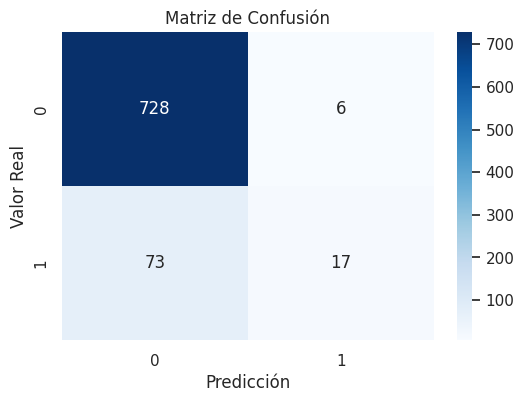

In [19]:
# 5.4: Grafique la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()


## 6. ¿Cuáles son las Variables Más Relevantes?

Esta es la segunda parte de la solicitud del banco. Necesitamos explicar *por qué* el modelo toma sus decisiones.

### 6.1. Importancia de Variables (Árbol de Decisión)

In [21]:
# 6.1.1: Extraer el modelo de árbol y el preprocesador del pipeline optimizado
# (Ya tenemos 'best_tree_model')
final_tree_model = best_tree_model.named_steps['model']
final_preprocessor = best_tree_model.named_steps['preprocessor']


# 6.1.2: Obtener los nombres de las características DESPUÉS del OneHotEncoding
feature_names = final_preprocessor.get_feature_names_out()


# 6.1.3: Obtener las importancias (del 'final_tree_model')
importances = final_tree_model.feature_importances_


# 6.1.4: Crear un DataFrame para visualizarlas, ordene de mayor a menor importancia
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

importance_df.head(10)

,feature,importance
2,num__pdays,0.80
0,num__age,0.10
38,cat__contact_telephone,0.06
3,num__previous,0.04
1,num__campaign,0.00
5,cat__job_blue-collar,0.00
6,cat__job_entrepreneur,0.00
7,cat__job_housemaid,0.00
4,cat__job_admin.,0.00
9,cat__job_retired,0.00


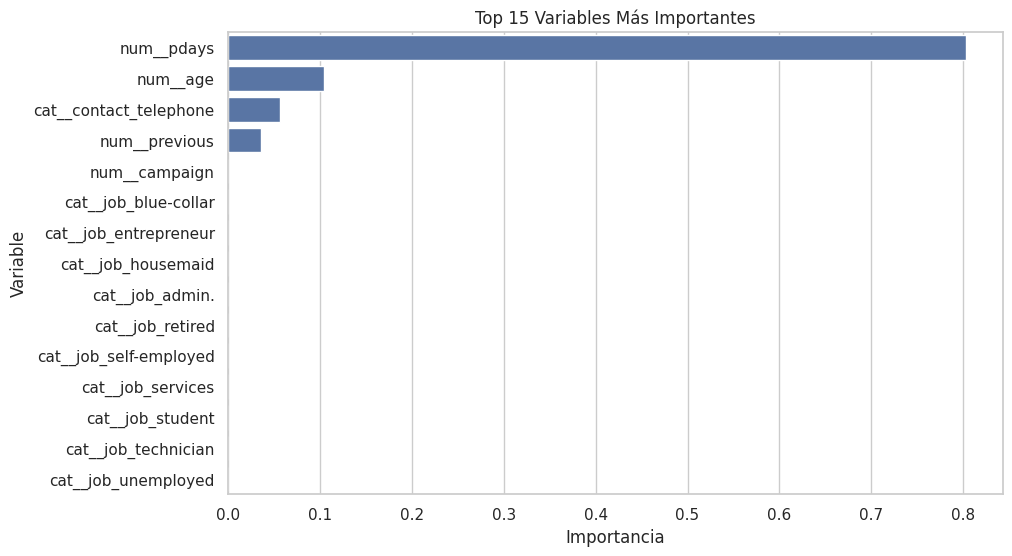

In [22]:
# 6.1.5: Grafique las 15 variables más importantes
top15 = importance_df.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top15,
    x='importance',
    y='feature'
)

plt.title('Top 15 Variables Más Importantes')
plt.xlabel('Importancia')
plt.ylabel('Variable')

plt.show()


## 7. Conclusión y Recomendación de Negocio

Es hora de traducir nuestros hallazgos en una recomendación de negocio clara.

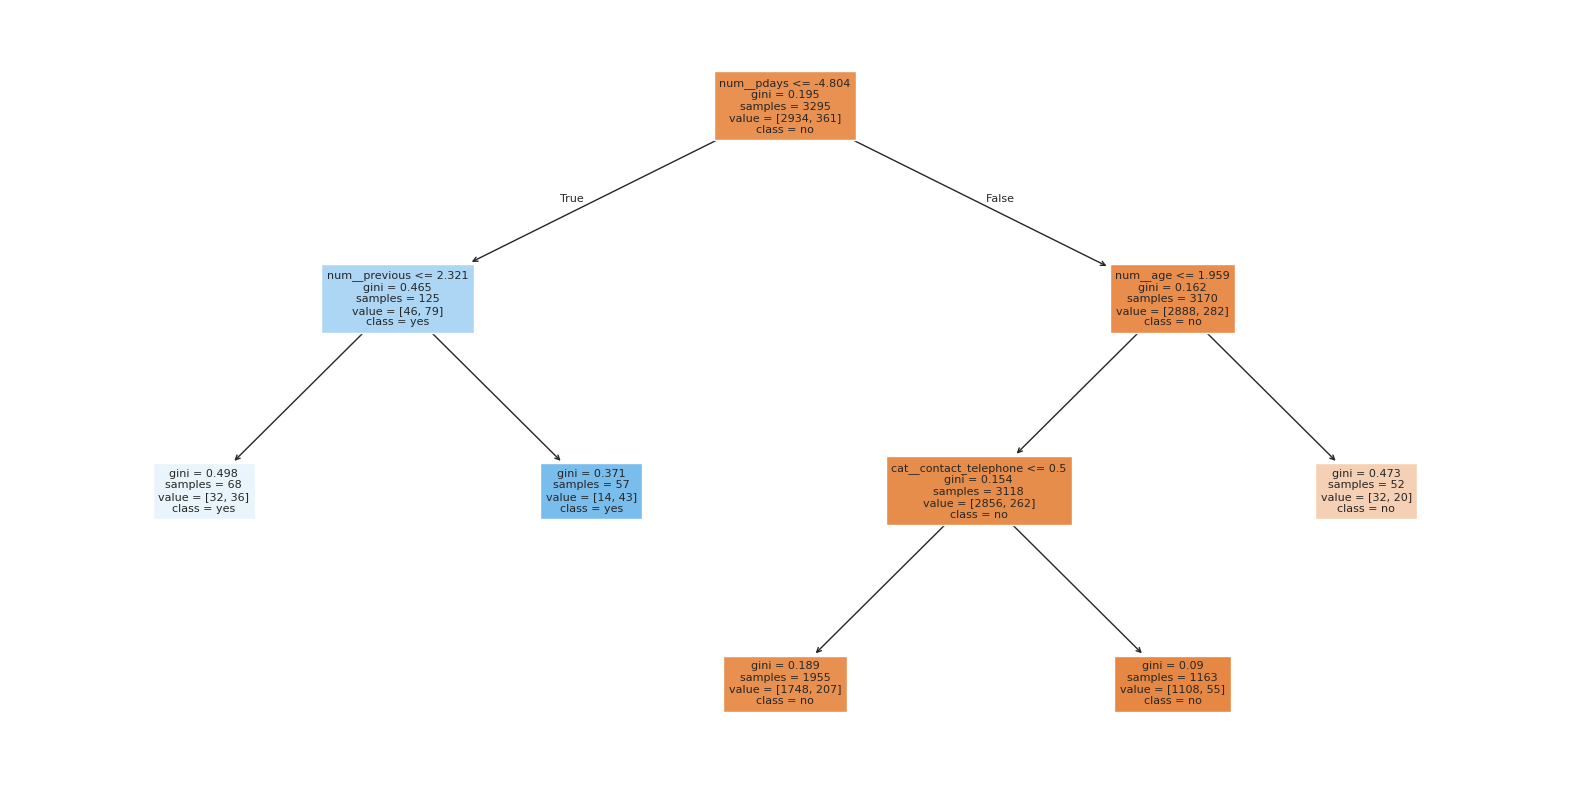

In [24]:
# 7.1: Grafique el árbol de decisión final para encontrar reglas
# (Use max_depth=3 para que sea legible)
plt.figure(figsize=(20,10))

plot_tree(
    final_tree_model,
    feature_names=feature_names,
    class_names=['no', 'yes'],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

### **7.2: Conclusiones Consultoría**

Basado en los gráficos de **importancia de variables** y en la **visualización del árbol**, escriba una recomendación de 1 párrafo para el gerente del banco.

**Recomendación:**

Con base en los resultados obtenidos, se recomienda utilizar el modelo de árbol de decisión, ya que ofrece un buen desempeño general y, además, es fácilmente interpretable para el banco. A diferencia de otros modelos más complejos, el árbol permite entender claramente qué variables influyen en la decisión y cómo se generan las predicciones. Según el gráfico de importancia de variables, las tres variables más relevantes son pdays, age y contact_telephone. Esto sugiere que el banco debería prestar especial atención al tiempo desde el último contacto con el cliente, la edad y el tipo de contacto utilizado al decidir a quién llamar en futuras campañas. Una regla importante observada en el árbol es que los clientes con valores bajos en pdays y con experiencias previas positivas (previous) tienen una mayor probabilidad de aceptar el depósito. En términos de negocio, esto indica que los clientes contactados recientemente y que ya han interactuado favorablemente con campañas anteriores representan oportunidades más prometedoras para el banco.
